# RQ1 & RQ2: Performance vs Energy Consumption Analysis

This notebook plots performance against energy consumption for all experiments:

**RQ1 (Single-Agent):** SA experiments across all models, modes, and prompting strategies
**RQ2 (Multi-Agent):** DA and MA experiments across all models, modes, and prompting strategies

**Models:**
- Qwen3-4B (4B parameters, MoE)
- Nemotron-Nano-8B (8B parameters, dense)
- Qwen3-30B-A3B (30B parameters, MoE)
- Nemotron-Super-49B (49B parameters, dense)

**Visual Encoding:**
- Color: Model size (4B/8B = blue/cyan, 30B/49B = purple/magenta)
- Shape: Mode (circle = Instruct, square = Thinking)
- Fill: Prompting (hollow = Zero-shot, filled = Few-shot)

**Date**: January 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')

# Base paths
from pathlib import Path
BASE_DIR = Path('..').resolve()
RESULTS_DIR = BASE_DIR / 'results'
ANALYSIS_DIR = RESULTS_DIR / 'analysis_combined'
ANALYSIS_DIR.mkdir(exist_ok=True)

print(f"Results directory: {RESULTS_DIR}")
print(f"Analysis output: {ANALYSIS_DIR}")

Results directory: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results
Analysis output: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results/analysis_combined


## 1. Load and Merge Data

In [2]:
# Load consolidated data
perf_df = pd.read_csv(RESULTS_DIR / 'consolidated_performance.csv')
emissions_df = pd.read_csv(RESULTS_DIR / 'consolidated_emissions.csv')

print(f"Performance records: {len(perf_df)}")
print(f"Emissions records: {len(emissions_df)}")

# Show breakdown
print("\nPerformance by design:")
print(perf_df.groupby(['design', 'task']).size().unstack(fill_value=0))

Performance records: 120
Emissions records: 120

Performance by design:
task    code_generation  log_analysis  vulnerability_detection
design                                                        
DA                   16             8                       16
MA                   16             8                       16
SA                   16             8                       16


In [3]:
# Merge on experiment key columns
merge_keys = ['model', 'model_family', 'parameters_b', 'design', 'task', 'mode', 'prompting']

# Select relevant columns from emissions
emissions_cols = merge_keys + ['total_energy_kwh', 'total_emissions_kg', 'total_duration_s', 
                                'duration_hours', 'emissions_g', 'num_sessions']
emissions_subset = emissions_df[emissions_cols].copy()

# Merge
merged_df = pd.merge(perf_df, emissions_subset, on=merge_keys, how='inner')
print(f"Merged records: {len(merged_df)}")

# Check for missing matches
if len(merged_df) < len(perf_df):
    print(f"\nWarning: {len(perf_df) - len(merged_df)} performance records have no matching emissions data")

Merged records: 120


In [4]:
# Add short labels for plotting
def make_short_label(row):
    """Create short label like '4B Inst F (DA)'"""
    params = row['parameters_b']
    model_abbr = f"{params}B"
    mode_abbr = 'Thin' if row['mode'] == 'thinking' else 'Inst'
    prompt_abbr = 'F' if row['prompting'] == 'few-shot' else 'Z'
    design = row['design']
    return f"{model_abbr} {mode_abbr} {prompt_abbr} ({design})"

merged_df['label'] = merged_df.apply(make_short_label, axis=1)

# Convert metrics to percentages
merged_df['f1_pct'] = merged_df['f1_score'] * 100
merged_df['accuracy_pct'] = merged_df['accuracy'] * 100
merged_df['pass_at_1_pct'] = merged_df['pass_at_1'] * 100

# Show sample
display_cols = ['label', 'task', 'total_energy_kwh', 'f1_pct', 'pass_at_1_pct']
merged_df[display_cols].head(10)

,label,task,total_energy_kwh,f1_pct,pass_at_1_pct
0,4B Inst F (DA),code_generation,0.107970,NaN,99.390244
1,4B Inst Z (DA),code_generation,0.062770,NaN,89.634146
2,4B Thin F (DA),code_generation,0.665064,NaN,88.414634
3,4B Thin Z (DA),code_generation,0.710241,NaN,90.853659
4,4B Inst F (DA),log_analysis,0.643200,6.172840,NaN
5,4B Inst Z (DA),log_analysis,0.636711,5.917160,NaN
6,4B Thin F (DA),log_analysis,8.135066,6.185567,NaN
7,4B Thin Z (DA),log_analysis,8.706342,7.058824,NaN
8,4B Inst F (DA),vulnerability_detection,0.226524,21.145374,NaN
9,4B Inst Z (DA),vulnerability_detection,0.276976,13.617021,NaN


## 2. Visual Encoding Configuration

In [5]:
# Color mapping by model size
MODEL_COLORS = {
    4: '#3498db',    # Blue for 4B
    8: '#00bcd4',    # Cyan for 8B
    30: '#9b59b6',   # Purple for 30B
    49: '#e91e63',   # Magenta/Pink for 49B
}

# Shape mapping by mode
MODE_MARKERS = {
    'instruct': 'o',   # Circle
    'thinking': 's',   # Square
}

# Size mapping by design (optional - can keep uniform)
DESIGN_SIZES = {
    'SA': 180,
    'DA': 180,
    'MA': 180,
}

print("Visual Encoding:")
print("  Color: Model size (4B=blue, 8B=cyan, 30B=purple, 49B=magenta)")
print("  Shape: Mode (circle=Instruct, square=Thinking)")
print("  Fill: Prompting (hollow=Zero-shot, filled=Few-shot)")

Visual Encoding:
  Color: Model size (4B=blue, 8B=cyan, 30B=purple, 49B=magenta)
  Shape: Mode (circle=Instruct, square=Thinking)
  Fill: Prompting (hollow=Zero-shot, filled=Few-shot)


## 3. Plotting Function

In [6]:
def plot_performance_vs_energy(df, task, y_metric, y_label, title_task, filename, 
                                designs=None, figsize=(14, 10)):
    """Create performance vs energy scatter plot with visual encoding."""
    
    # Filter to task
    task_df = df[df['task'] == task].dropna(subset=[y_metric, 'total_energy_kwh']).copy()
    
    # Filter to specific designs if provided
    if designs:
        task_df = task_df[task_df['design'].isin(designs)]
        design_str = ' & '.join(designs)
    else:
        design_str = 'SA & DA & MA'
    
    if len(task_df) == 0:
        print(f"No data for {task}")
        return None
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot each point
    for _, row in task_df.iterrows():
        x = row['total_energy_kwh']
        y = row[y_metric]
        
        # Get visual properties
        color = MODEL_COLORS.get(row['parameters_b'], 'gray')
        marker = MODE_MARKERS.get(row['mode'], 'o')
        size = DESIGN_SIZES.get(row['design'], 180)
        
        # Fill based on prompting
        if row['prompting'] == 'zero-shot':
            facecolor = 'white'
            edgewidth = 2.5
        else:
            facecolor = color
            edgewidth = 1.5
        
        ax.scatter(x, y, marker=marker, s=size,
                   facecolors=facecolor, edgecolors=color, 
                   linewidths=edgewidth, zorder=5, alpha=0.9)
        
        # Add label
        ax.annotate(row['label'], (x, y),
                    textcoords='offset points', xytext=(8, 4),
                    fontsize=8, color='dimgray',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', 
                              edgecolor='none', alpha=0.7))
    
    # Labels and title
    ax.set_xlabel('Energy Consumption (kWh)', fontsize=12)
    ax.set_ylabel(y_label, fontsize=12)
    ax.set_title(f'Performance vs Energy Consumption: {title_task}\n'
                 f'4B & 8B & 30B & 49B | Instruct & Thinking | Zero-shot & Few-shot | {design_str}',
                 fontsize=13)
    ax.grid(True, alpha=0.3)
    
    # Create legend
    legend_elements = [
        # Colors (model size)
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db',
               markeredgecolor='#3498db', markersize=10, label='4B Models'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#00bcd4',
               markeredgecolor='#00bcd4', markersize=10, label='8B Models'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#9b59b6',
               markeredgecolor='#9b59b6', markersize=10, label='30B Models'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#e91e63',
               markeredgecolor='#e91e63', markersize=10, label='49B Models'),
        # Shapes (mode)
        Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
               markeredgecolor='gray', markersize=10, label='Instruct'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='gray',
               markeredgecolor='gray', markersize=10, label='Thinking'),
        # Fill (prompting)
        Line2D([0], [0], marker='o', color='w', markerfacecolor='white',
               markeredgecolor='gray', markersize=10, linewidth=2, label='Zero-shot'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
               markeredgecolor='gray', markersize=10, label='Few-shot'),
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=9, 
              framealpha=0.95, ncol=1)
    
    plt.tight_layout()
    plt.savefig(ANALYSIS_DIR / filename, dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Saved: {ANALYSIS_DIR / filename}")
    return task_df

## 4. Vulnerability Detection Plots

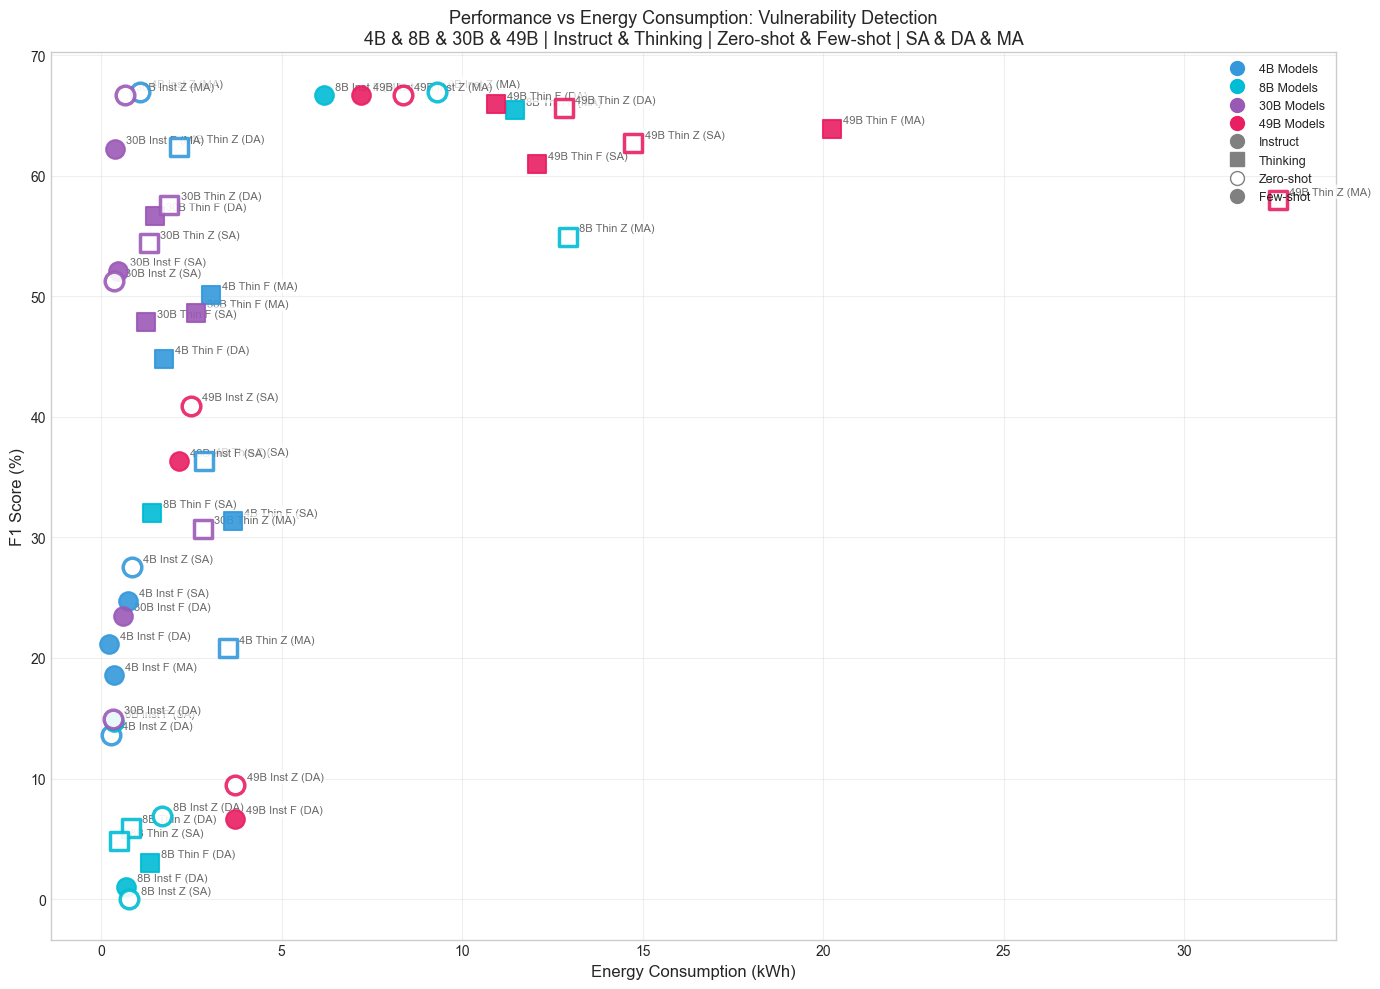

Saved: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results/analysis_combined/perf_vs_energy_vuln_all.png


In [7]:
# All designs (SA + DA + MA)
vuln_all = plot_performance_vs_energy(
    merged_df,
    task='vulnerability_detection',
    y_metric='f1_pct',
    y_label='F1 Score (%)',
    title_task='Vulnerability Detection',
    filename='perf_vs_energy_vuln_all.png'
)

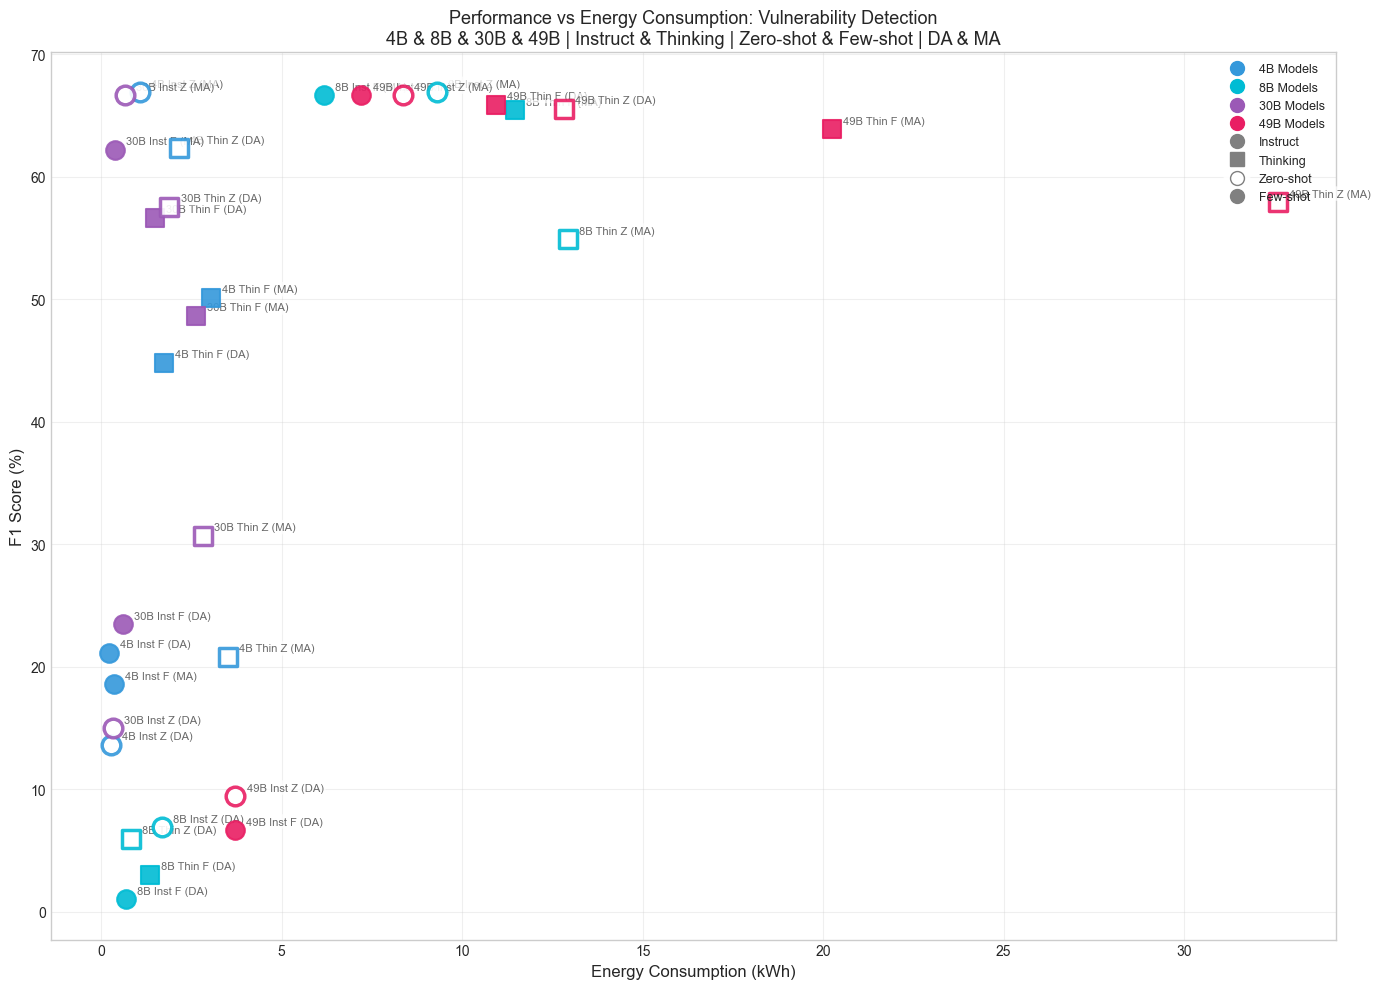

Saved: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results/analysis_combined/perf_vs_energy_vuln_da_ma.png


In [8]:
# DA + MA only (Multi-Agent focus)
vuln_da_ma = plot_performance_vs_energy(
    merged_df,
    task='vulnerability_detection',
    y_metric='f1_pct',
    y_label='F1 Score (%)',
    title_task='Vulnerability Detection',
    filename='perf_vs_energy_vuln_da_ma.png',
    designs=['DA', 'MA']
)

## 5. Code Generation Plots

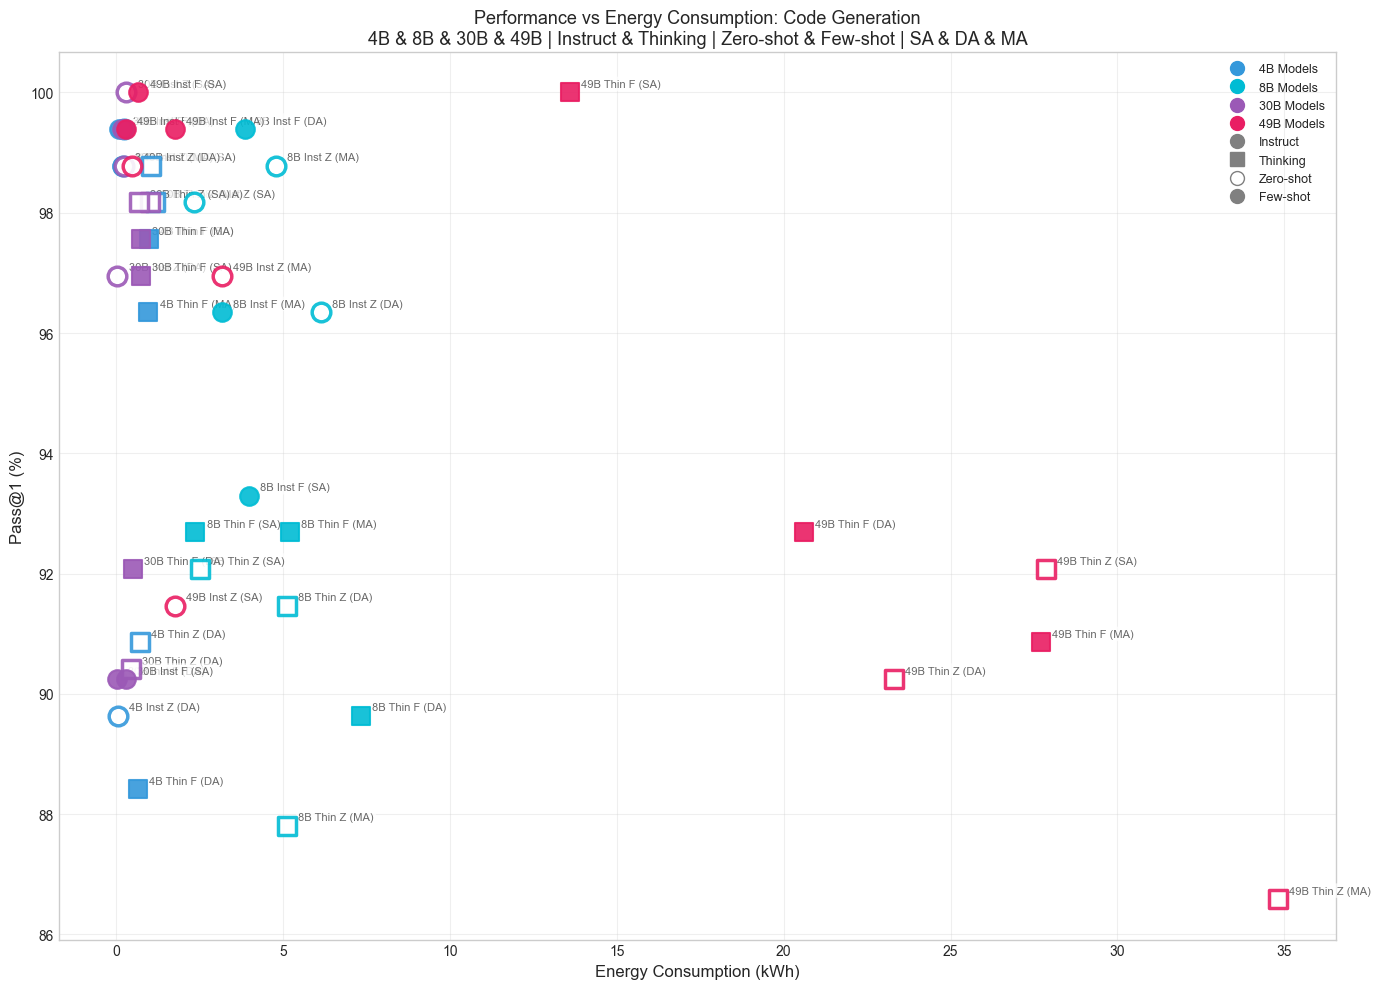

Saved: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results/analysis_combined/perf_vs_energy_code_all.png


In [9]:
# All designs (SA + DA + MA)
code_all = plot_performance_vs_energy(
    merged_df,
    task='code_generation',
    y_metric='pass_at_1_pct',
    y_label='Pass@1 (%)',
    title_task='Code Generation',
    filename='perf_vs_energy_code_all.png'
)

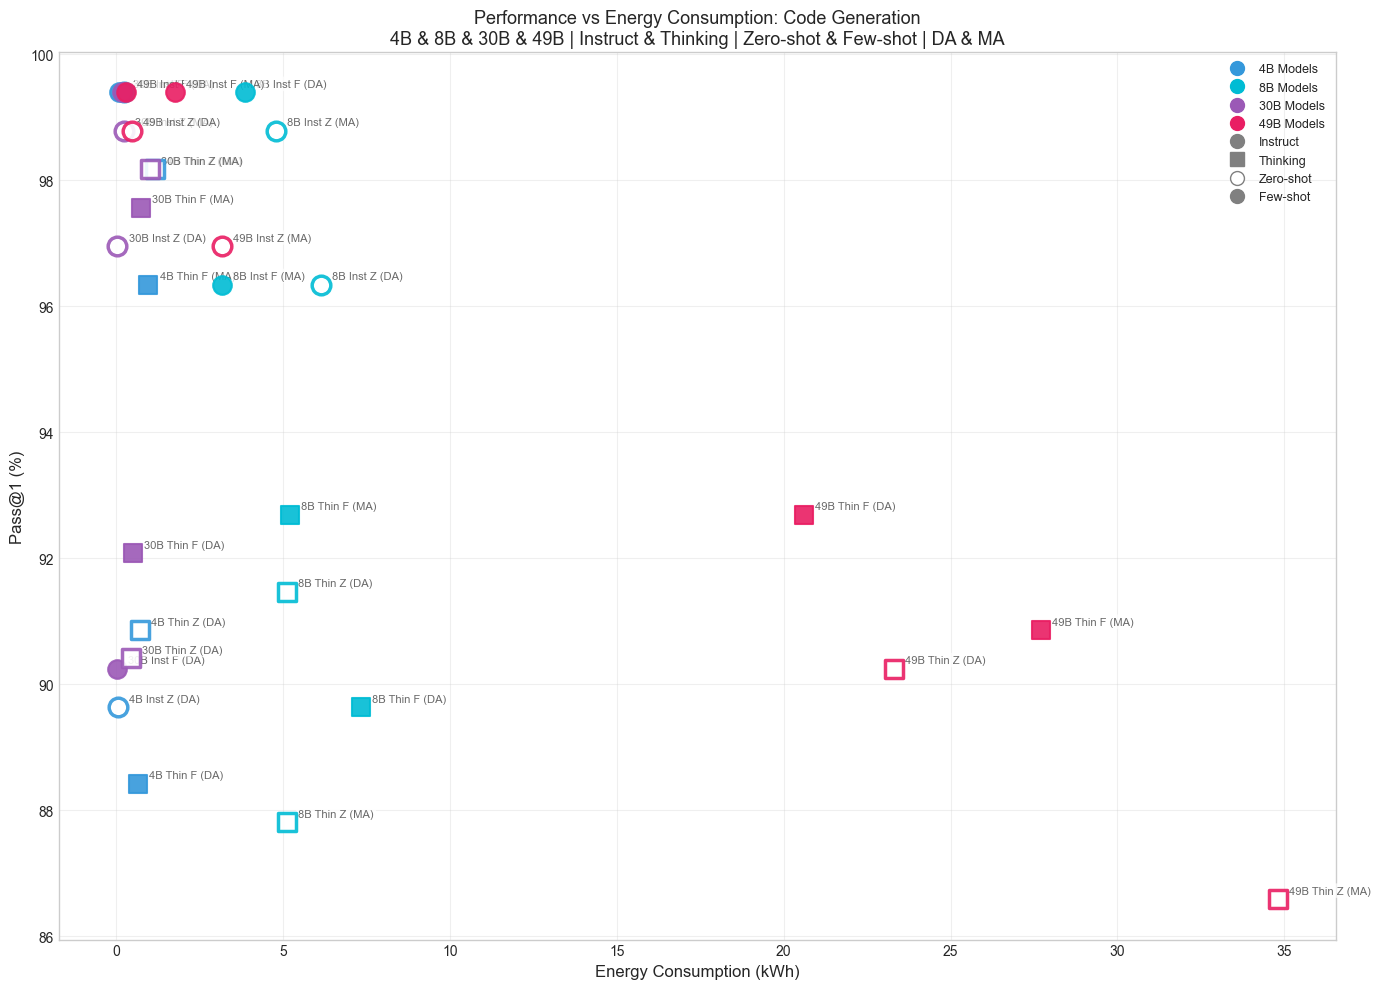

Saved: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results/analysis_combined/perf_vs_energy_code_da_ma.png


In [10]:
# DA + MA only (Multi-Agent focus)
code_da_ma = plot_performance_vs_energy(
    merged_df,
    task='code_generation',
    y_metric='pass_at_1_pct',
    y_label='Pass@1 (%)',
    title_task='Code Generation',
    filename='perf_vs_energy_code_da_ma.png',
    designs=['DA', 'MA']
)

## 6. Summary Statistics

In [11]:
print("="*80)
print("SUMMARY: VULNERABILITY DETECTION")
print("="*80)

vuln_summary = merged_df[merged_df['task'] == 'vulnerability_detection'].groupby(
    ['parameters_b', 'design']
).agg({
    'f1_pct': 'mean',
    'accuracy_pct': 'mean',
    'total_energy_kwh': 'mean',
    'skipped_samples': 'sum'
}).round(2)

print(vuln_summary)

SUMMARY: VULNERABILITY DETECTION
                     f1_pct  accuracy_pct  total_energy_kwh  skipped_samples
parameters_b design                                                         
4            DA       35.49         50.39              1.10                0
             MA       39.10         50.55              2.00                0
             SA       29.98         52.40              2.02                0
8            DA        4.22         50.52              1.14                0
             MA       63.48         51.63              9.97                0
             SA       12.88         49.09              0.77                0
30           DA       38.17         50.19              1.08                0
             MA       52.07         51.33              1.62                0
             SA       51.40         54.79              0.84                0
49           DA       36.90         50.84              7.80                0
             MA       63.79         52.08  

In [12]:
print("="*80)
print("SUMMARY: CODE GENERATION")
print("="*80)

code_summary = merged_df[merged_df['task'] == 'code_generation'].groupby(
    ['parameters_b', 'design']
).agg({
    'pass_at_1_pct': 'mean',
    'total_energy_kwh': 'mean',
    'passed_samples': 'sum',
    'failed_samples': 'sum'
}).round(2)

print(code_summary)

SUMMARY: CODE GENERATION
                     pass_at_1_pct  total_energy_kwh  passed_samples  \
parameters_b design                                                    
4            DA              92.07              0.39           604.0   
             MA              98.32              0.65           645.0   
             SA              98.48              0.61           646.0   
8            DA              94.21              5.62           618.0   
             MA              93.90              4.58           616.0   
             SA              94.05              2.81           617.0   
30           DA              92.42              0.26           590.0   
             MA              98.48              0.55           646.0   
             SA              96.34              0.52           632.0   
49           DA              95.27             11.18           625.0   
             MA              93.45             16.87           613.0   
             SA              95.88     

In [13]:
# Energy efficiency rankings
print("="*80)
print("ENERGY EFFICIENCY RANKINGS")
print("="*80)

# Vulnerability: F1 per kWh
vuln_data = merged_df[merged_df['task'] == 'vulnerability_detection'].copy()
vuln_data['f1_per_kwh'] = vuln_data['f1_pct'] / vuln_data['total_energy_kwh']

print("\nVulnerability Detection - Top 10 by F1%/kWh (higher is better):")
vuln_eff = vuln_data.nlargest(10, 'f1_per_kwh')[['label', 'f1_pct', 'total_energy_kwh', 'f1_per_kwh']]
print(vuln_eff.to_string(index=False))

# Code: Pass@1 per kWh
code_data = merged_df[merged_df['task'] == 'code_generation'].copy()
code_data['pass1_per_kwh'] = code_data['pass_at_1_pct'] / code_data['total_energy_kwh']

print("\nCode Generation - Top 10 by Pass@1%/kWh (higher is better):")
code_eff = code_data.nlargest(10, 'pass1_per_kwh')[['label', 'pass_at_1_pct', 'total_energy_kwh', 'pass1_per_kwh']]
print(code_eff.to_string(index=False))

ENERGY EFFICIENCY RANKINGS

Vulnerability Detection - Top 10 by F1%/kWh (higher is better):
          label    f1_pct  total_energy_kwh  f1_per_kwh
30B Inst F (MA) 62.240664          0.383636  162.238914
30B Inst Z (SA) 51.239669          0.348762  146.918633
30B Inst F (SA) 52.124646          0.477449  109.173203
30B Inst Z (MA) 66.666667          0.664664  100.301340
 4B Inst F (DA) 21.145374          0.226524   93.347334
 4B Inst Z (MA) 66.897747          1.066736   62.712559
 4B Inst F (MA) 18.565401          0.352151   52.720074
 4B Inst Z (DA) 13.617021          0.276976   49.163267
30B Inst Z (DA) 14.977974          0.317048   47.241976
30B Thin Z (SA) 54.400000          1.316173   41.331954

Code Generation - Top 10 by Pass@1%/kWh (higher is better):
          label  pass_at_1_pct  total_energy_kwh  pass1_per_kwh
30B Inst F (DA)      90.243902          0.027695    3258.521947
30B Inst Z (DA)      96.951220          0.049013    1978.052794
 4B Inst Z (DA)      89.634146         

In [14]:
# Save merged data for further analysis
merged_df.to_csv(ANALYSIS_DIR / 'performance_energy_merged.csv', index=False)
print(f"Saved merged data to: {ANALYSIS_DIR / 'performance_energy_merged.csv'}")

print("\nGenerated plots:")
for f in sorted(ANALYSIS_DIR.glob('perf_vs_energy_*.png')):
    print(f"  - {f.name}")

Saved merged data to: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results/analysis_combined/performance_energy_merged.csv

Generated plots:
  - perf_vs_energy_code_all.png
  - perf_vs_energy_code_da_ma.png
  - perf_vs_energy_vuln_all.png
  - perf_vs_energy_vuln_da_ma.png
